# Model C — Regularized CNN

In this notebook we evaluate the effect of regularization on CNN performance. In Model B we used three convolutional blocks with 32, 64, and 128 filters.

In Model C we will use the same convolutional architecture and add Data Augmentation, Batch Normalization, and Dropout. All other training conditions are kept identical for a fair comparison. Our goal in this part is to test the impact of regularization on model generalization and classification performance.

In [1]:
from pathlib import Path
import sys
import json
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Asus\Desktop\AID-Scene_Classification


In [2]:
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from project_utils import (
    SEED,
    EPOCHS,
    TARGET_CLASSES,
    RESULTS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
    set_seed,
    load_datasets,
    build_cnn,
)

In [3]:
set_seed()

train_ds, val_ds, test_ds = load_datasets()

for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 160, 160, 3)
Labels shape: (32,)


In [4]:
# Model C configuration: regularized CNN with Data Augmentation, Batch Normalization, and Dropout
model_c_config = {
    "name": "model_c_regularized",
    "filters": [32, 64, 128],
    "kernel_size": 3,
    "augmentation": True,
    "batch_norm": True,
    "dense_units": 64,
    "dropout": 0.3,
}

In [5]:
tf.keras.backend.clear_session()
set_seed()

model_c = build_cnn(
    num_classes=len(TARGET_CLASSES),
    config=model_c_config,
)

model_c.summary()

model_c_params = model_c.count_params()

print(f"Total parameters: {model_c_params:,}")

Model: "model_c_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,826 (401.66 KB)

 Trainable params: 102,378 (399.91 KB)

 Non-trainable params: 448 (1.75 KB)

Total parameters: 102,826


In [6]:
#model compile
model_c.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [7]:
start_time_c = time.time()

history_c = model_c.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    #callbacks=callbacks_c,
)

train_time_sec_c = time.time() - start_time_c

print(
    f"\nTraining time: {train_time_sec_c:.1f} "
    f"sec for {EPOCHS} epochs"
)

Epoch 1/15


c:\Users\Asus\Desktop\AID-Scene_Classification\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


77/77 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.4570 - loss: 1.5485 - val_accuracy: 0.1837 - val_loss: 2.7870
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.5564 - loss: 1.2416 - val_accuracy: 0.1705 - val_loss: 3.8960
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.5779 - loss: 1.1574 - val_accuracy: 0.1326 - val_loss: 4.3753
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.6193 - loss: 1.0595 - val_accuracy: 0.1534 - val_loss: 4.9209
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.6351 - loss: 0.9952 - val_accuracy: 0.2178 - val_loss: 3.2099
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6627 - loss: 0.9412 - val_accuracy: 0.3125 - val_loss: 2.6646
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.6774 - loss: 0.9011 - val_accuracy: 0.4830 - val_loss: 1.5269
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.6956 - loss: 0.8243 - val_accuracy: 0.5114 - val_loss: 1.

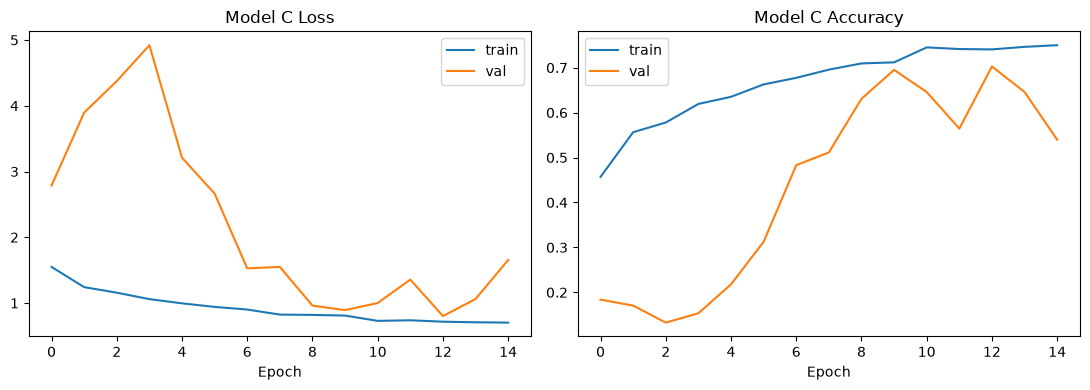

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_c.history["loss"], label="train")
axes[0].plot(history_c.history["val_loss"], label="val")
axes[0].set_title("Model C Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_c.history["accuracy"], label="train")
axes[1].plot(history_c.history["val_accuracy"], label="val")
axes[1].set_title("Model C Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_c_curves.png"), dpi=120)
plt.show()

Model C test accuracy: 0.5284 | test loss: 1.5571


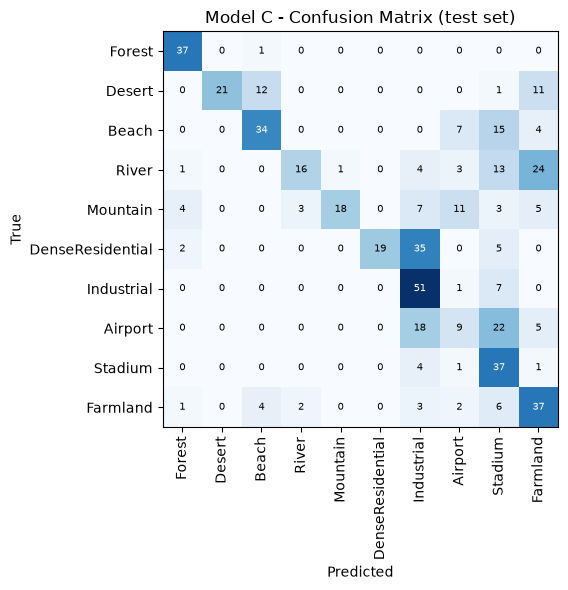

                  precision    recall  f1-score   support

          Forest       0.82      0.97      0.89        38
          Desert       1.00      0.47      0.64        45
           Beach       0.67      0.57      0.61        60
           River       0.76      0.26      0.39        62
        Mountain       0.95      0.35      0.51        51
DenseResidential       1.00      0.31      0.47        61
      Industrial       0.42      0.86      0.56        59
         Airport       0.26      0.17      0.20        54
         Stadium       0.34      0.86      0.49        43
        Farmland       0.43      0.67      0.52        55

        accuracy                           0.53       528
       macro avg       0.66      0.55      0.53       528
    weighted avg       0.66      0.53      0.52       528



In [9]:
test_loss_c , test_acc_c = model_c.evaluate(test_ds, verbose=0)
print(f"Model C test accuracy: {test_acc_c:.4f} | test loss: {test_loss_c:.4f}")

y_true_c, y_pred_c = [], []
for imgs, labels in test_ds:
    probs = model_c.predict(imgs, verbose=0)
    y_true_c.extend(labels.numpy().tolist())
    y_pred_c.extend(np.argmax(probs, axis=1).tolist())

cm = confusion_matrix(y_true_c, y_pred_c)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(TARGET_CLASSES))); ax.set_xticklabels(TARGET_CLASSES, rotation=90)
ax.set_yticks(range(len(TARGET_CLASSES))); ax.set_yticklabels(TARGET_CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Model C - Confusion Matrix (test set)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_c_confusion_matrix.png"), dpi=120)
plt.show()

print(classification_report(y_true_c, y_pred_c, target_names=TARGET_CLASSES))

In [10]:
model_c.save(
    os.path.join(ARTIFACTS_DIR, "model_c_regularized.keras")
)

history_out = {
    "model": "model_c_regularized",
    "config": model_c_config,
    "epochs": EPOCHS,
    "train_time_sec": float(train_time_sec_c),
    "n_params": int(model_c_params),
    "test_accuracy": float(test_acc_c),
    "test_loss": float(test_loss_c),
    "history": {
        k: [float(v) for v in vals]
        for k, vals in history_c.history.items()
    },
}

with open(
    os.path.join(RESULTS_DIR, "model_c_history.json"),
    "w"
) as f:
    json.dump(history_out, f, indent=2)


print(
    "Saved model to",
    os.path.join(ARTIFACTS_DIR, "model_c_regularized.keras")
)

print(
    "Saved training history to",
    os.path.join(RESULTS_DIR, "model_c_history.json")
)

Saved model to C:\Users\Asus\Desktop\AID-Scene_Classification\artifacts\model_c_regularized.keras
Saved training history to C:\Users\Asus\Desktop\AID-Scene_Classification\results\model_c_history.json


## Findings